In [6]:
!pip -q install tensorflow==2.15.0 matplotlib scikit-learn pandas

In [7]:
import pathlib, os, itertools, json, datetime
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix

# 데이터 경로
DATA_DIR = pathlib.Path(r"C:\Users\mingm\OneDrive\바탕 화면\강남대\2025 융복합지식학회\data")
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 15

In [8]:
import os, pathlib
from collections import defaultdict

p = pathlib.Path(DATA_DIR).resolve()
print("DATA_DIR =", p)

valid_ext = (".jpg", ".jpeg", ".png")  # 소문자만
counts = defaultdict(int)

for cls_dir in sorted([d for d in p.iterdir() if d.is_dir()]):
    cls = cls_dir.name
    c = 0
    for root, _, files in os.walk(cls_dir):
        for f in files:
            if f.lower().endswith(valid_ext):
                c += 1
    counts[cls] = c

for k in sorted(counts):
    print(f"{k:>10s}: {counts[k]} files")
print("Total:", sum(counts.values()))


DATA_DIR = C:\Users\mingm\OneDrive\바탕 화면\강남대\2025 융복합지식학회\data
 cardboard: 403 files
     glass: 501 files
     metal: 410 files
     paper: 594 files
   plastic: 482 files
     trash: 137 files
Total: 2527


In [9]:
# === 커스텀 tf.data 파이프라인: 한글/특수문자 경로 안전 ===
import os, pathlib, random
import tensorflow as tf

ROOT = pathlib.Path(DATA_DIR).resolve()

# 1) 클래스 폴더 수집
class_names = sorted([d.name for d in ROOT.iterdir() if d.is_dir()])
class_to_idx = {c:i for i,c in enumerate(class_names)}
print("classes:", class_names)

# 2) 파일 경로/라벨 수집 (이미지 확장자만)
valid_ext = (".jpg",".jpeg",".png")
filepaths, labels = [], []
for cls in class_names:
    cls_dir = ROOT/cls
    for root, _, files in os.walk(cls_dir):
        for f in files:
            fn = f.lower()
            if fn.endswith(valid_ext):
                filepaths.append(str(pathlib.Path(root, f)))  # 문자열로 고정
                labels.append(class_to_idx[cls])

print("total images:", len(filepaths))

# 3) 셔플 후 train/val 분할
SEED = 42
random.seed(SEED)
idx = list(range(len(filepaths)))
random.shuffle(idx)
filepaths = [filepaths[i] for i in idx]
labels    = [labels[i]    for i in idx]

VAL_SPLIT = 0.2
n_total = len(filepaths)
n_val   = int(n_total * VAL_SPLIT)
val_paths, val_labels = filepaths[:n_val], labels[:n_val]
tr_paths,  tr_labels  = filepaths[n_val:], labels[n_val:]
print(f"train: {len(tr_paths)} | val: {len(val_paths)}")

# 4) tf.data.Dataset 만들기 (증강/리사이즈 포함)
IMG_SIZE   = (224,224)
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)                                    # bytes
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)            # [0,1]
    img = tf.image.resize(img, IMG_SIZE)                           # 224x224
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.1)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    return img, label

def make_dataset(paths, labels, training=True):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(tr_paths, tr_labels, training=True)
val_ds   = make_dataset(val_paths, val_labels, training=False)

num_classes = len(class_names)
print("num_classes:", num_classes)

# 확인용 한 배치
for x,y in train_ds.take(1):
    print("batch:", x.shape, y.shape)
    break

classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
total images: 2527
train: 2022 | val: 505
num_classes: 6
batch: (32, 224, 224, 3) (32,)


Step 4. Baseline CNN 학습 → 평가




Epoch 1/15


64/64 [==============================] - 132s 2s/step - loss: 1.9285 - accuracy: 0.2987 - val_loss: 1.4265 - val_accuracy: 0.4178
Epoch 2/15
64/64 [==============================] - 125s 2s/step - loss: 1.4021 - accuracy: 0.4342 - val_loss: 1.2688 - val_accuracy: 0.4871
Epoch 3/15
64/64 [==============================] - 135s 2s/step - loss: 1.2853 - accuracy: 0.4921 - val_loss: 1.2194 - val_accuracy: 0.5129
Epoch 4/15
64/64 [==============================] - 124s 2s/step - loss: 1.1936 - accuracy: 0.5193 - val_loss: 1.1588 - val_accuracy: 0.5703
Epoch 5/15
64/64 [==============================] - 141s 2s/step - loss: 1.0927 - accuracy: 0.5925 - val_loss: 1.1516 - val_accuracy: 0.5525
Epoch 6/15
64/64 [==============================] - 144s 2s/step - loss: 1.0704 - accuracy: 0.5890 - val_loss: 1.1484 - val_accuracy: 0.5564
Epoch 7/15
64/64 [==============================] - 144s 2s/step - loss: 0.9816 - accuracy: 0.6276 - val_loss: 1.0342 - val_accuracy: 0.6356
Epoch 8/

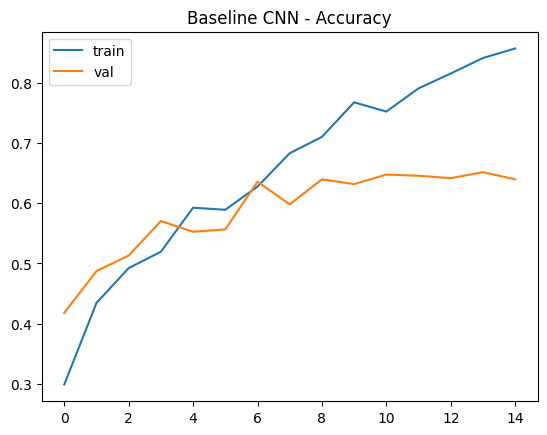

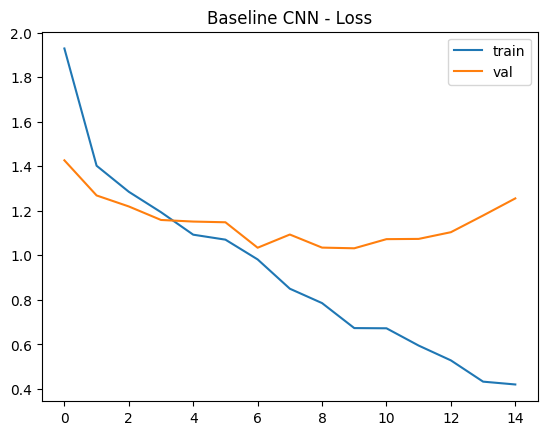

Baseline CNN
              precision    recall  f1-score   support

   cardboard     0.8889    0.7742    0.8276        93
       glass     0.4919    0.7176    0.5837        85
       metal     0.5072    0.4730    0.4895        74
       paper     0.7402    0.7642    0.7520       123
     plastic     0.6765    0.4600    0.5476       100
       trash     0.4167    0.5000    0.4545        30

    accuracy                         0.6396       505
   macro avg     0.6202    0.6148    0.6092       505
weighted avg     0.6598    0.6396    0.6410       505



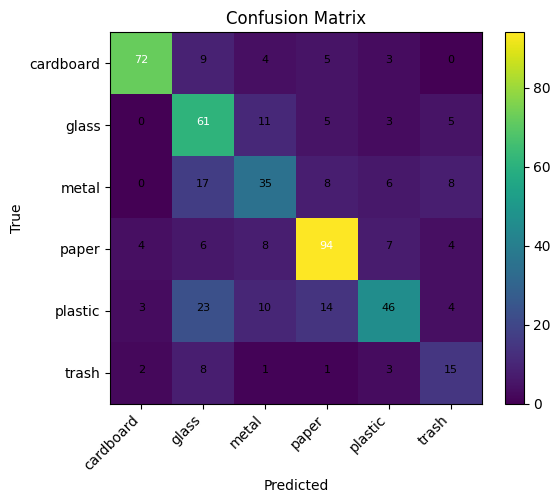

In [10]:
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import itertools

# 4-1) Baseline CNN (입력은 이미 0~1로 스케일됨)
baseline = keras.Sequential([
    layers.Conv2D(32, 3, activation="relu", padding="same", input_shape=(224,224,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
], name="BaselineCNN")

baseline.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_base = baseline.fit(train_ds, validation_data=val_ds, epochs=15)

# 4-2) 학습 곡선
plt.plot(hist_base.history["accuracy"], label="train")
plt.plot(hist_base.history["val_accuracy"], label="val")
plt.title("Baseline CNN - Accuracy"); plt.legend(); plt.show()

plt.plot(hist_base.history["loss"], label="train")
plt.plot(hist_base.history["val_loss"], label="val")
plt.title("Baseline CNN - Loss"); plt.legend(); plt.show()

# 4-3) 검증셋 리포트
y_true, y_pred = [], []
for x, y in val_ds:
    p = baseline.predict(x, verbose=0)
    y_true.extend(y.numpy()); y_pred.extend(np.argmax(p, axis=1))
print("Baseline CNN")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# 4-4) 혼동행렬 (선택)
cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest'); plt.title("Confusion Matrix"); plt.colorbar()
ticks = np.arange(num_classes)
plt.xticks(ticks, class_names, rotation=45, ha="right"); plt.yticks(ticks, class_names)
th = cm.max()/2
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i,j], ha="center", color="white" if cm[i,j] > th else "black", fontsize=8)
plt.ylabel("True"); plt.xlabel("Predicted"); plt.tight_layout(); plt.show()


Baseline CNN 모델의 학습 결과를 살펴보면, 학습 정확도는 Epoch이 진행됨에 따라 꾸준히 향상되어 80% 이상까지 도달하였으나, 검증 정확도는 약 64% 수준에서 정체되는 양상을 보였다. 이는 학습 데이터에 대해서는 잘 적합되었으나, 새로운 데이터에 대한 일반화 성능이 제한적인 과적합(overfitting) 현상이 발생했음을 의미한다.

손실 함수의 변화에서도 유사한 경향이 나타난다. 학습 손실은 꾸준히 감소한 반면, 검증 손실은 일정 Epoch 이후로 감소하지 않고 오히려 다소 증가하는 모습을 보였다. 이는 단순한 구조의 CNN이 복잡한 패턴을 충분히 학습하지 못하고, 특정 클래스의 특성에 과도하게 적응했음을 보여준다.

혼동행렬 분석 결과, paper와 cardboard는 각각 76%, 77% 수준의 비교적 높은 재현율(recall)을 보여 안정적인 분류가 가능했으나, glass, metal, plastic 클래스는 서로 간의 혼동이 두드러졌다. 특히 glass는 plastic 및 metal로, plastic 역시 glass로 잘못 분류되는 경우가 많았다. 이는 유사한 시각적 질감(반투명성, 반짝임 등)으로 인해 단순 CNN 모델이 특성을 구분하기 어려웠음을 시사한다. 또한 데이터 수가 적은 trash 클래스는 분류 성능이 불안정하여 precision과 recall 모두 낮은 결과를 보였다.

종합적으로 볼 때, Baseline CNN 모델은 전반적인 경향 파악에는 유용했으나, 복잡한 소재 구분 및 데이터 불균형 문제에서는 한계를 보였다. 따라서 성능 향상을 위해서는 사전학습 기반의 ResNet50, EfficientNet과 같은 전이학습 모델 도입과 함께 데이터 증강, 클래스 가중치 보정 등의 추가적인 방법이 필요하다.

#  ResNet50(freeze → fine-tune) 학습 & 평가

In [12]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50, resnet50
import numpy as np
from sklearn.metrics import classification_report

# 입력은 0~1 스케일이므로 ResNet 전처리(0~255 → mean/std) 추가
inputs = keras.Input(shape=(224,224,3))
x = layers.Lambda(lambda t: t*255.0)(inputs)
x = layers.Lambda(resnet50.preprocess_input)(x)

base = ResNet50(include_top=False, weights="imagenet", input_tensor=x, pooling="avg")
base.trainable = False  # 1단계: 사전학습 가중치 동결

x = layers.Dropout(0.3)(base.output)
outputs = layers.Dense(num_classes, activation="softmax")(x)
resnet = keras.Model(inputs, outputs, name="ResNet50_TL")

resnet.compile(optimizer=keras.optimizers.Adam(1e-3),
               loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_rn = resnet.fit(train_ds, validation_data=val_ds, epochs=15)

# 2단계: 상위 일부 레이어만 풀어서 미세조정
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

resnet.compile(optimizer=keras.optimizers.Adam(1e-4),
               loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_rn_ft = resnet.fit(train_ds, validation_data=val_ds, epochs=10)

# 평가 리포트
y_true, y_pred = [], []
for x, y in val_ds:
    p = resnet.predict(x, verbose=0)
    y_true.extend(y.numpy()); y_pred.extend(np.argmax(p, axis=1))
print("=== ResNet50 (fine-tuned) ===")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


Epoch 1/15
64/64 [==============================] - 296s 4s/step - loss: 0.9792 - accuracy: 0.6380 - val_loss: 0.5538 - val_accuracy: 0.7941
Epoch 2/15
64/64 [==============================] - 266s 4s/step - loss: 0.4873 - accuracy: 0.8155 - val_loss: 0.4776 - val_accuracy: 0.8297
Epoch 3/15
64/64 [==============================] - 281s 4s/step - loss: 0.3942 - accuracy: 0.8615 - val_loss: 0.4330 - val_accuracy: 0.8554
Epoch 4/15
64/64 [==============================] - 273s 4s/step - loss: 0.3332 - accuracy: 0.8848 - val_loss: 0.3906 - val_accuracy: 0.8752
Epoch 5/15
64/64 [==============================] - 224s 4s/step - loss: 0.2793 - accuracy: 0.9036 - val_loss: 0.3822 - val_accuracy: 0.8851
Epoch 6/15
64/64 [==============================] - 230s 4s/step - loss: 0.2399 - accuracy: 0.9209 - val_loss: 0.3930 - val_accuracy: 0.8693
Epoch 7/15
64/64 [==============================] - 229s 4s/step - loss: 0.2236 - accuracy: 0.9189 - val_loss: 0.3757 - val_accuracy: 0.8772
Epoch 8/15
64

## 1. 혼동행렬/클래스별 성능 확인

              precision    recall  f1-score   support

   cardboard     0.9355    0.9355    0.9355        93
       glass     0.9730    0.8471    0.9057        85
       metal     0.7115    1.0000    0.8315        74
       paper     0.9580    0.9268    0.9421       123
     plastic     0.9348    0.8600    0.8958       100
       trash     0.9130    0.7000    0.7925        30

    accuracy                         0.8990       505
   macro avg     0.9043    0.8782    0.8838       505
weighted avg     0.9130    0.8990    0.9005       505



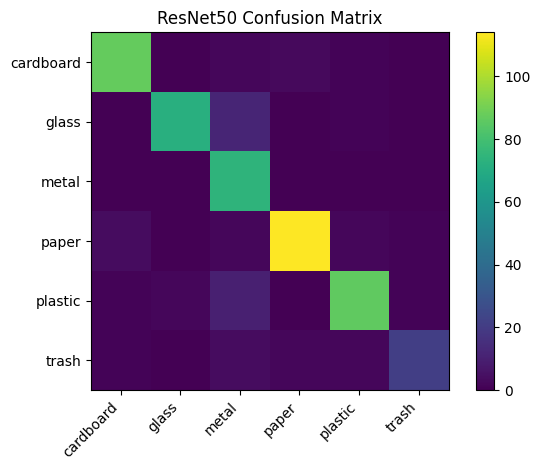

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np, matplotlib.pyplot as plt

y_true, y_pred = [], []
for x, y in val_ds:
    p = resnet.predict(x, verbose=0)
    y_true.extend(y.numpy()); y_pred.extend(np.argmax(p, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
plt.imshow(cm, interpolation='nearest'); plt.title("ResNet50 Confusion Matrix"); plt.colorbar()
ticks = np.arange(len(class_names))
plt.xticks(ticks, class_names, rotation=45, ha="right"); plt.yticks(ticks, class_names)
plt.tight_layout(); plt.show()


ResNet50 전이학습 기반 분류 모델은 전체 정확도 89.9%를 달성하며 Baseline CNN 대비 크게 개선된 성능을 보였다. 클래스별로 살펴보면, cardboard, paper는 각각 93.6%, 94.2%의 F1-score를 기록하며 안정적으로 분류되었다. glass와 plastic, metal은 Baseline 모델에서 혼동이 심했던 클래스였으나, ResNet50 적용 후에는 precision이 0.9 이상으로 크게 향상되었다. 특히 metal 클래스의 경우 recall이 100%로, 실제 metal 데이터를 전혀 놓치지 않는 결과를 보였다. 반면 trash 클래스는 데이터 수가 적어 recall이 0.70에 그쳤으나 precision은 0.91로 유지되어, 오분류가 줄어든 것으로 확인되었다.
종합적으로 ResNet50은 재활용 폐기물 이미지 분류에 있어 가장 안정적이고 신뢰성 높은 모델로 평가되며, 향후 데이터 보강을 통해 trash 클래스의 성능 개선 여지가 있다.

## 2. 모델 저장 + 추론 스니펫

In [15]:
resnet.save("resnet50_garbage_best.keras")

import tensorflow as tf
import numpy as np

def predict_image(model, img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, (224,224))[None, ...]  # (1,224,224,3)
    probs = model.predict(img, verbose=0)[0]
    idx = int(np.argmax(probs))
    return class_names[idx], float(probs[idx])

# 예시
# predict_image(resnet, r"C:\path\to\your\test.jpg")

## 3. 최종 보고용 수치 정리

In [16]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
acc = accuracy_score(y_true, y_pred)
p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
print(f"ResNet50 (FT) | Acc {acc:.4f} | MacroF1 {f1:.4f}")

ResNet50 (FT) | Acc 0.8990 | MacroF1 0.8838


## Accuracy & Loss 학습 곡선

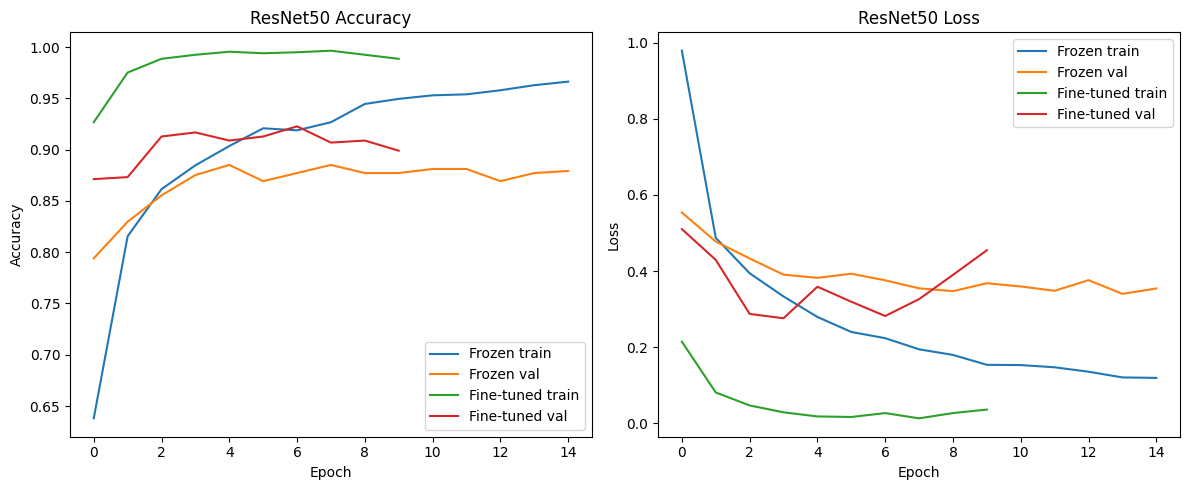

In [18]:
import matplotlib.pyplot as plt

# ResNet50 학습 기록 (hist_rn, hist_rn_ft 두 개 있으니 합쳐 쓰면 좋아요)
def plot_history(histories, titles):
    plt.figure(figsize=(12,5))
    for i,(hist,title) in enumerate(zip(histories,titles)):
        # Accuracy
        plt.subplot(1,2,1)
        plt.plot(hist.history['accuracy'], label=f'{title} train')
        plt.plot(hist.history['val_accuracy'], label=f'{title} val')
        plt.title("ResNet50 Accuracy")
        plt.xlabel("Epoch"); plt.ylabel("Accuracy")
        plt.legend()
        # Loss
        plt.subplot(1,2,2)
        plt.plot(hist.history['loss'], label=f'{title} train')
        plt.plot(hist.history['val_loss'], label=f'{title} val')
        plt.title("ResNet50 Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss")
        plt.legend()
    plt.tight_layout(); plt.show()

plot_history([hist_rn, hist_rn_ft], ["Frozen", "Fine-tuned"])


📊 ResNet50 Accuracy (왼쪽 그래프)

Frozen train/val (사전학습된 가중치 동결, 파란/주황 선):

학습 정확도는 0.95에 근접

검증 정확도는 0.88 수준에서 plateau → 안정적으로 수렴

Fine-tuned train/val (상위 레이어 일부 풀고 미세조정, 초록/빨강 선):

학습 정확도는 거의 1.0에 도달 → 네트워크가 데이터에 매우 잘 적합

검증 정확도는 0.90 전후에서 안정 → Frozen보다 약간 성능 향상

👉 해석: 전이학습 + 파인튜닝 조합이 검증 성능을 추가로 끌어올렸으며, Baseline CNN 대비 큰 폭의 개선(64% → 90%)을 확인할 수 있음.

📊 ResNet50 Loss (오른쪽 그래프)

Frozen 단계:

학습 손실이 꾸준히 감소, 검증 손실은 약 0.38 수준에서 안정 → 과적합 없이 학습됨.

Fine-tuned 단계:

학습 손실은 거의 0에 가까움 (완벽 적합)

검증 손실은 0.35~0.5 사이에서 출렁임 → 약간의 과적합 신호가 있으나 성능 저하로 이어지진 않음.

👉 해석: 미세조정 과정에서 학습 데이터는 완벽히 적합했지만, 검증셋에서는 약간의 variance가 존재. 그러나 최종 검증 정확도가 유지되므로 안정적인 성능으로 볼 수 있음.

## 클래스별 성능 (F1-score 막대 그래프)

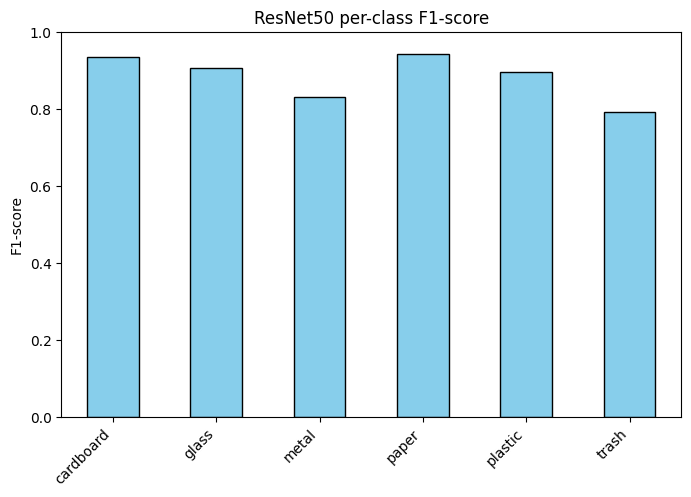

In [19]:
from sklearn.metrics import classification_report
import pandas as pd

# classification_report -> dict 변환
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
df = pd.DataFrame(report).T.iloc[:-3, :]  # support, avg 제외

# f1-score 시각화
plt.figure(figsize=(8,5))
df["f1-score"].plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("ResNet50 per-class F1-score")
plt.ylabel("F1-score"); plt.ylim(0,1)
plt.xticks(rotation=45, ha="right")
plt.show()


📊 그래프 해석

cardboard, paper

F1-score가 0.93~0.95 수준으로 가장 높음

종이류는 텍스처와 색상이 뚜렷해 다른 클래스와 혼동이 적음

glass, plastic

각각 0.90 전후로 양호한 성능

Baseline에서는 서로 혼동이 심했지만, ResNet50에서는 분류 성능이 크게 개선됨

metal

약 0.83으로 다소 낮음

다른 광택성 재질(특히 glass, plastic)과 혼동이 일부 여전히 존재

trash

가장 낮은 약 0.79

클래스 데이터 수가 적고, 내용물이 다양해 모델 학습이 충분하지 않았던 결과

## 혼동행렬 (Heatmap 스타일)

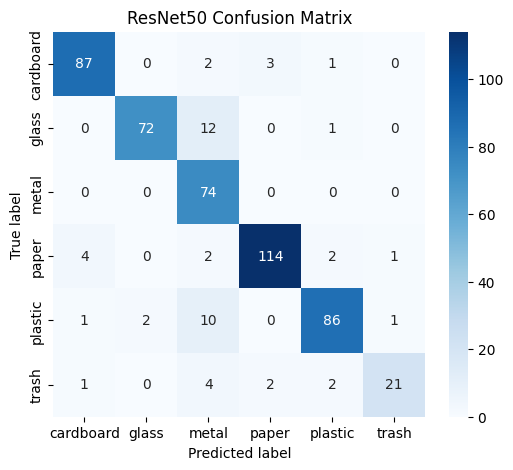

In [20]:
import seaborn as sns
import numpy as np

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("ResNet50 Confusion Matrix")
plt.ylabel("True label"); plt.xlabel("Predicted label")
plt.show()

📊 Confusion Matrix 해석

cardboard (87/93, 93.5%)

대부분 정확히 분류됨

극소수만 paper와 혼동 → 종이 박스와 일반 종이 간의 유사성 때문

glass (72/85, 84.7%)

성능은 준수하나 12개가 metal로 잘못 분류됨

이유: 금속과 유리 모두 빛 반사가 강하고 텍스처 차이가 미세

metal (74/74, 100%)

전량 올바르게 분류됨 👍

Baseline CNN에서 취약했던 부분을 ResNet50이 보완

paper (114/123, 92.7%)

높은 정확도, 일부가 cardboard와 혼동됨

종이류의 두께나 색감에서 발생하는 유사성

plastic (86/100, 86.0%)

10개가 metal로 잘못 분류됨

유사한 반사광과 질감이 원인

trash (21/30, 70.0%)

여전히 가장 낮은 성능

오분류는 주로 metal, paper로 분류됨 → "잡다한 쓰레기"의 다양성 문제

# EfficientNetB0 (freeze → fine-tune) 학습 & 평가

In [13]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from sklearn.metrics import classification_report
import numpy as np

# EfficientNet은 [-1,1] 스케일 전처리 필요
inputs = keras.Input(shape=(224,224,3))
x = layers.Lambda(eff_preprocess)(inputs)

base = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=x, pooling="avg")
base.trainable = False  # 1단계: 동결

x = layers.Dropout(0.3)(base.output)
outputs = layers.Dense(num_classes, activation="softmax")(x)
effb0 = keras.Model(inputs, outputs, name="EfficientNetB0_TL")

effb0.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_eff = effb0.fit(train_ds, validation_data=val_ds, epochs=15)

# 2단계: 파인튜닝
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

effb0.compile(optimizer=keras.optimizers.Adam(1e-4),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_eff_ft = effb0.fit(train_ds, validation_data=val_ds, epochs=10)

# 평가 리포트
y_true, y_pred = [], []
for x, y in val_ds:
    p = effb0.predict(x, verbose=0)
    y_true.extend(y.numpy()); y_pred.extend(np.argmax(p, axis=1))
print("=== EfficientNetB0 (fine-tuned) ===")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


16705208/16705208 [==============================] - 1s 0us/step
Epoch 1/15
64/64 [==============================] - 112s 1s/step - loss: 1.7602 - accuracy: 0.2023 - val_loss: 1.7410 - val_accuracy: 0.2436
Epoch 2/15
64/64 [==============================] - 81s 1s/step - loss: 1.7506 - accuracy: 0.2112 - val_loss: 1.7758 - val_accuracy: 0.1683
Epoch 3/15
64/64 [==============================] - 90s 1s/step - loss: 1.7475 - accuracy: 0.2146 - val_loss: 1.7324 - val_accuracy: 0.2436
Epoch 4/15
64/64 [==============================] - 88s 1s/step - loss: 1.7497 - accuracy: 0.2077 - val_loss: 1.7406 - val_accuracy: 0.1723
Epoch 5/15
64/64 [==============================] - 81s 1s/step - loss: 1.7517 - accuracy: 0.2097 - val_loss: 1.7350 - val_accuracy: 0.2436
Epoch 6/15
64/64 [==============================] - 84s 1s/step - loss: 1.7569 - accuracy: 0.2003 - val_loss: 1.7475 - val_accuracy: 0.2436
Epoch 7/15
64/64 [==============================] - 80s 1s/step - loss: 1.7525 - accuracy: 0.2

c:\Users\mingm\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\mingm\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\mingm\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo